# Dataset Demo - Satellite Lightning: MTG LI

This notebook demonstrates the use of [EUMETSAT's Meteosat Third Generation Lighning Imager (MTG LI)](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide) datset with PyEarthTools.

### EW4Energy Dataset info
* Duration: 6 months -  April to September 2025
* Temporal Resoltuion file per 15 minutes (20MB per file)
* Spatial Extent
  * Latitude 0N to 20N
  * Longitude 27W to 20E


### Set up libraries

In [ ]:
import os
import pathlib

In [ ]:
import numpy
import scipy
import scipy.interpolate

In [ ]:
import matplotlib
import cartopy

In [ ]:
import xarray

In [ ]:
import site_archive_jasmin

In [ ]:
import pyearthtools
import pyearthtools.data

### Load sample data

In [7]:
mtg_sample_path = pathlib.Path('/gws/nopw/j04/ew4energy/MTG_LI/20250422/flash_accumulation_20250422094500_15mins.nc')

In [8]:
mtg_li_ds = xarray.open_dataset(mtg_sample_path)

In [9]:
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Dimensions without coordinates: y, x
Data variables:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [10]:

float(mtg_li_ds['latitude'].min()), float(mtg_li_ds['latitude'].max()), float(mtg_li_ds['longitude'].min()) , float(mtg_li_ds['longitude'].max())

(0.027131086215376854,
 20.190547943115234,
 -27.115114212036133,
 19.97930908203125)

(array([2.461435e+06, 2.970000e+02, 7.000000e+01, 5.700000e+01,
        3.800000e+01, 3.600000e+01, 1.200000e+01, 1.000000e+01,
        5.000000e+00, 6.000000e+00]),
 array([ 0.        ,  2.28830004,  4.57660007,  6.86490011,  9.15320015,
        11.44149971, 13.72980022, 16.01810074, 18.3064003 , 20.59469986,
        22.88300133]),
 <BarContainer object of 10 artists>)

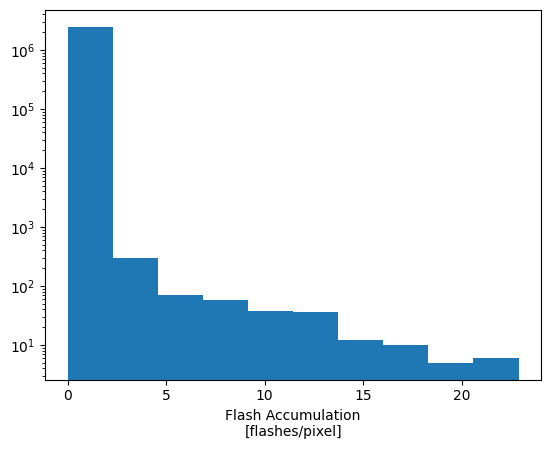

In [11]:
mtg_li_ds['flash_accumulation'].plot.hist(log=True)

In [12]:
float((mtg_li_ds['flash_accumulation']>0).sum().values), float(mtg_li_ds['flash_accumulation'].sum().values)

(14621.0, 5870.763671875)

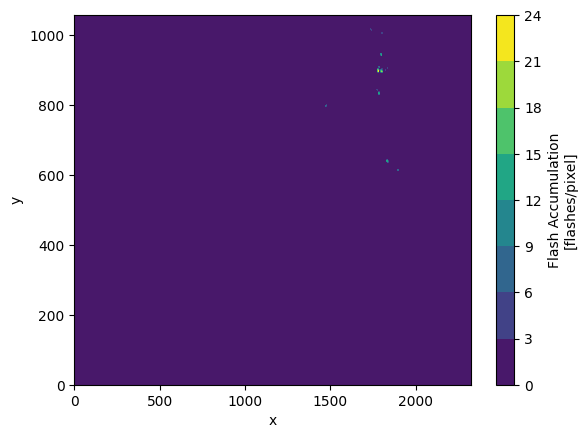

In [13]:
mtg_li_ds['flash_accumulation'].plot.contourf()

### Regridding to a regular grid 

This data has an issue where the latitude and longitude fields are not correctly interpreted as coordinates. In addition it is not clear what projection is used by the data.

In [14]:
mtg_li_ds = mtg_li_ds.set_coords(['latitude','longitude'])
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Coordinates:
    latitude            (y, x) float32 10MB 20.19 20.19 ... 0.02742 0.02742
    longitude           (y, x) float32 10MB -27.12 -27.09 -27.07 ... 18.5 18.52
Dimensions without coordinates: y, x
Data variables:
    flash_accumulation  (y, x) float32 10MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [15]:
mtg_li_ds.set_coords(["latitude", "longitude"])

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Coordinates:
    latitude            (y, x) float32 10MB 20.19 20.19 ... 0.02742 0.02742
    longitude           (y, x) float32 10MB -27.12 -27.09 -27.07 ... 18.5 18.52
Dimensions without coordinates: y, x
Data variables:
    flash_accumulation  (y, x) float32 10MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [16]:
da = mtg_li_ds["flash_accumulation"]

lat2d = mtg_li_ds["latitude"].values
lon2d = mtg_li_ds["longitude"].values
values = da.values

In [17]:
# Define target regular grid
lat_out = numpy.arange(numpy.nanmin(lat2d), numpy.nanmax(lat2d), 0.05)
lon_out = numpy.arange(numpy.nanmin(lon2d), numpy.nanmax(lon2d), 0.05)


In [18]:
lon_grid, lat_grid = numpy.meshgrid(lon_out, lat_out)

In [19]:
# Flatten source points
points = numpy.column_stack([lon2d.ravel(), lat2d.ravel()])
data = values.ravel()

In [20]:
# Remove missing values
valid = numpy.isfinite(points[:, 0]) & numpy.isfinite(points[:, 1]) & numpy.isfinite(data)


In [21]:
regridded = scipy.interpolate.griddata(
    points[valid],
    data[valid],
    (lon_grid, lat_grid),
    method="linear",   # or "nearest"
)

In [22]:
mtg_li_ds_clean = xarray.Dataset(
    data_vars={
        "flash_accumulation": (("latitude", "longitude"), regridded)
    },
    coords={
        "latitude": lat_out,
        "longitude": lon_out,
    },
)

In [23]:
mtg_li_ds_clean['flash_accumulation']


<xarray.DataArray 'flash_accumulation' (latitude: 404, longitude: 942)> Size: 3MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan,  0.,  0., ..., nan, nan, nan],
       [nan,  0.,  0., ..., nan, nan, nan],
       [nan,  0.,  0., ..., nan, nan, nan]], shape=(404, 942))
Coordinates:
  * latitude   (latitude) float64 3kB 0.02713 0.07713 0.1271 ... 20.13 20.18
  * longitude  (longitude) float64 8kB -27.12 -27.07 -27.02 ... 19.88 19.93

In [24]:
float((mtg_li_ds_clean['flash_accumulation']>0).sum().values), float(mtg_li_ds_clean['flash_accumulation'].sum().values)

(2198.0, 790.9684766362734)

(array([3.63113e+05, 4.50000e+01, 1.00000e+01, 8.00000e+00, 4.00000e+00,
        4.00000e+00, 4.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([ 0.        ,  2.28830013,  4.57660027,  6.8649004 ,  9.15320053,
        11.44150066, 13.7298008 , 16.01810093, 18.30640106, 20.59470119,
        22.88300133]),
 <BarContainer object of 10 artists>)

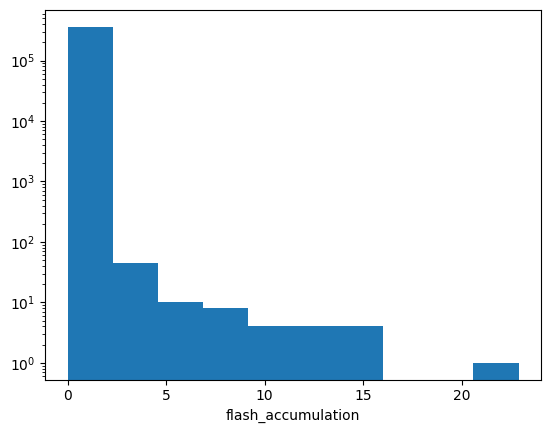

In [25]:
mtg_li_ds_clean['flash_accumulation'].plot.hist(log=True)

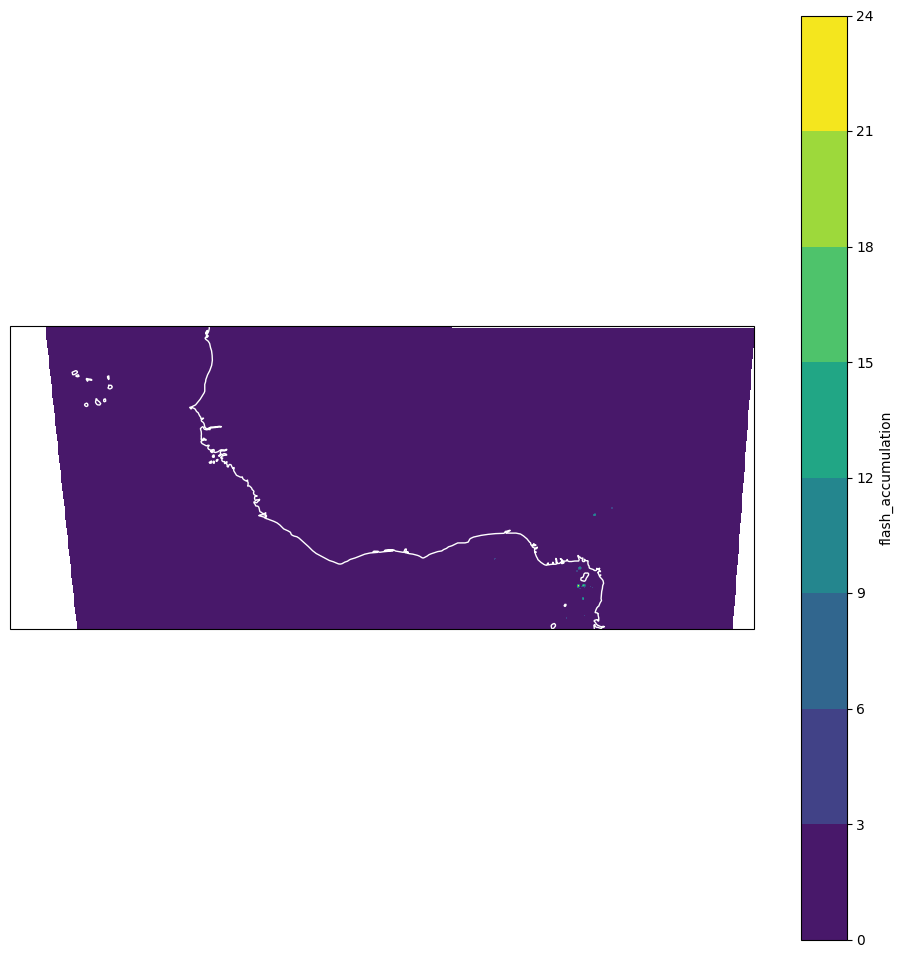

In [26]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
mtg_li_ds_clean['flash_accumulation'].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

## Load and process data through pyearthtools

In [27]:
pyearthtools.data.time.TimeDelta

pyearthtools.data.time.TimeDelta

In [28]:
pyearthtools.data.time.Petdt('2025-04-01 10:00') + pyearthtools.data.time.TimeDelta('00:00:00')

Petdt('2025-04-01T10:00')